In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

prices = pd.read_csv(
    "five_stock_prices.csv",
    index_col=0,
    parse_dates=True
)

print(prices.head())
print("\nColumns:", prices.columns.tolist())
print("\nMissing values:", prices.isna().sum())

                  AAPL          BLK          GS         JPM        MSFT
Date                                                                   
2025-09-23  253.493591  1108.070068  790.766968  306.869354  505.074463
2025-09-24  251.381409  1104.378906  777.144836  307.536621  505.986908
2025-09-25  255.924637  1123.284790  779.429932  307.566071  502.892334
2025-09-26  254.519806  1132.253052  787.030518  310.127045  507.286194
2025-09-29  253.493591  1150.963501  788.609436  309.764008  510.400513

Columns: ['AAPL', 'BLK', 'GS', 'JPM', 'MSFT']

Missing values: AAPL    1
BLK     1
GS      1
JPM     1
MSFT    1
dtype: int64


In [3]:

# Use dates where all five stocks have valid prices
clean_prices = prices.dropna()

# Calculate daily returns
returns = clean_prices.pct_change().dropna()

# Annualized historical return and covariance
annual_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

print("Observations:", len(returns))
print("\nAnnualized historical returns:")
display((annual_returns * 100).round(2).to_frame("Return (%)"))

print("\nAnnualized covariance matrix:")
display(cov_matrix.round(4))

Observations: 249

Annualized historical returns:


,Return (%)
AAPL,32.45
BLK,2.13
GS,24.73
JPM,16.37
MSFT,4.53



Annualized covariance matrix:


,AAPL,BLK,GS,JPM,MSFT
AAPL,0.0605,0.0195,0.0174,0.0099,0.0100
BLK,0.0195,0.0757,0.0475,0.0284,0.0182
GS,0.0174,0.0475,0.1038,0.0453,0.0160
JPM,0.0099,0.0284,0.0453,0.0494,0.0052
MSFT,0.0100,0.0182,0.0160,0.0052,0.1067


In [4]:

n = len(returns.columns)

# Start with equal weights
equal_weights = np.ones(n) / n

def portfolio_volatility(weights):
    return np.sqrt(weights @ cov_matrix.values @ weights)

result = minimize(
    portfolio_volatility,
    x0=equal_weights,
    method="SLSQP",
    bounds=[(0, 1)] * n,
    constraints=[{
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    }],
    options={"ftol": 1e-12, "maxiter": 1000}
)

if not result.success:
    raise RuntimeError(result.message)

min_var_weights = result.x

comparison = pd.DataFrame({
    "Equal Weight (%)": equal_weights * 100,
    "Minimum Variance (%)": min_var_weights * 100
}, index=returns.columns)

display(comparison.round(2))

print(
    f"Equal-weight volatility: "
    f"{portfolio_volatility(equal_weights):.2%}"
)
print(
    f"Minimum-variance volatility: "
    f"{portfolio_volatility(min_var_weights):.2%}"
)

,Equal Weight (%),Minimum Variance (%)
AAPL,20.0,32.18
BLK,20.0,6.90
GS,20.0,0.00
JPM,20.0,42.00
MSFT,20.0,18.92


Equal-weight volatility: 18.23%
Minimum-variance volatility: 16.39%


In [5]:

# Calculate each stock's contribution to portfolio risk
def risk_contributions(weights):
    cov = cov_matrix.values
    volatility = np.sqrt(weights @ cov @ weights)
    marginal_risk = cov @ weights / volatility
    return weights * marginal_risk

# Minimize differences between percentage risk contributions
def risk_parity_objective(weights):
    contributions = risk_contributions(weights)
    risk_shares = contributions / contributions.sum()
    target = np.ones(len(weights)) / len(weights)
    return np.sum((risk_shares - target) ** 2)

rp_result = minimize(
    risk_parity_objective,
    x0=equal_weights,
    method="SLSQP",
    bounds=[(0.0001, 1)] * n,
    constraints=[{
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    }],
    options={"ftol": 1e-12, "maxiter": 1000}
)

if not rp_result.success:
    raise RuntimeError(rp_result.message)

risk_parity_weights = rp_result.x

# Compare all three portfolios
weights_comparison = pd.DataFrame({
    "Equal Weight (%)": equal_weights * 100,
    "Minimum Variance (%)": min_var_weights * 100,
    "Risk Parity (%)": risk_parity_weights * 100
}, index=returns.columns)

display(weights_comparison.round(2))

# Verify that risk contributions are approximately equal
rp_risk_shares = risk_contributions(risk_parity_weights)
rp_risk_shares /= rp_risk_shares.sum()

print("\nRisk-parity risk contributions:")
display(pd.Series(
    rp_risk_shares * 100,
    index=returns.columns,
    name="Risk Contribution (%)"
).round(2))

,Equal Weight (%),Minimum Variance (%),Risk Parity (%)
AAPL,20.0,32.18,24.51
BLK,20.0,6.90,17.46
GS,20.0,0.00,14.78
JPM,20.0,42.00,23.17
MSFT,20.0,18.92,20.08



Risk-parity risk contributions:


AAPL    20.0
BLK     20.0
GS      20.0
JPM     20.0
MSFT    20.0
Name: Risk Contribution (%), dtype: float64

In [6]:

# Assumed annual risk-free rate
risk_free_rate = 0.04

portfolios = {
    "Equal Weight": equal_weights,
    "Minimum Variance": min_var_weights,
    "Risk Parity": risk_parity_weights
}

results = []

for name, weights in portfolios.items():
    expected_return = weights @ annual_returns.values
    volatility = portfolio_volatility(weights)
    sharpe = (
        (expected_return - risk_free_rate) / volatility
    )

    results.append({
        "Portfolio": name,
        "Expected Return (%)": expected_return * 100,
        "Volatility (%)": volatility * 100,
        "Sharpe Ratio": sharpe
    })

performance = pd.DataFrame(results).set_index("Portfolio")

display(performance.round(2))

,Expected Return (%),Volatility (%),Sharpe Ratio
Portfolio,,,
Equal Weight,16.04,18.23,0.66
Minimum Variance,18.32,16.39,0.87
Risk Parity,16.68,17.54,0.72


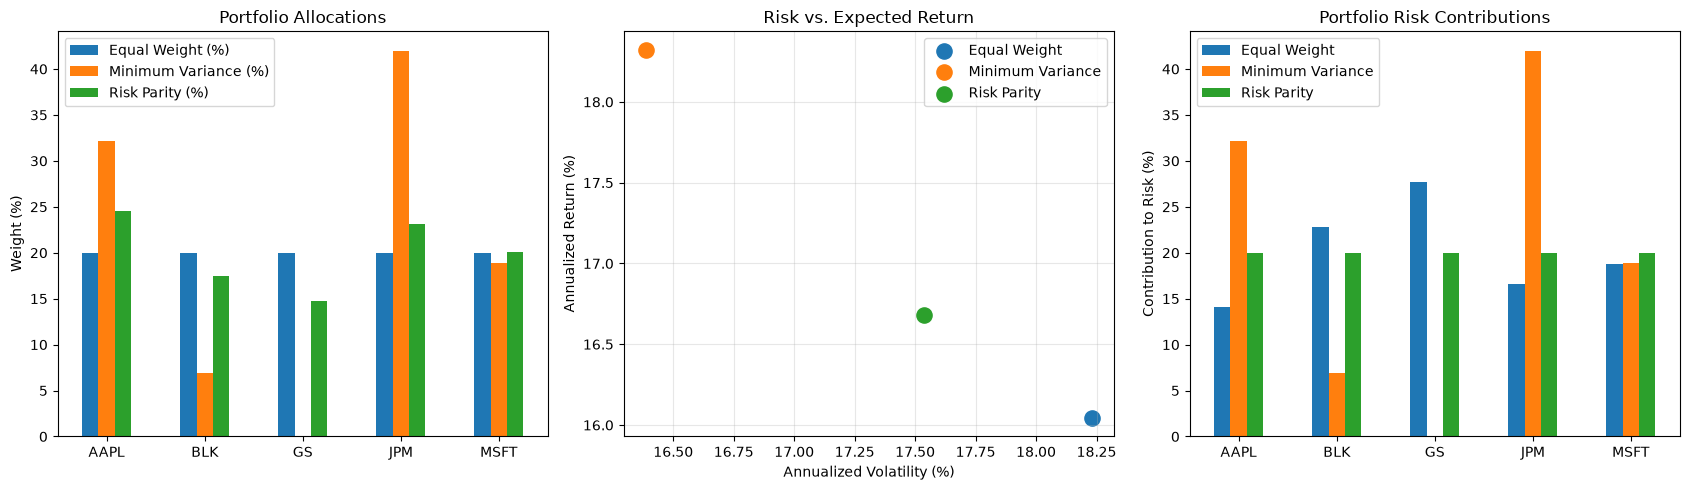

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Chart 1: Portfolio allocations
weights_comparison.plot(
    kind="bar",
    ax=axes[0],
    title="Portfolio Allocations"
)
axes[0].set_ylabel("Weight (%)")
axes[0].tick_params(axis="x", rotation=0)

# Chart 2: Expected return versus volatility
for name, row in performance.iterrows():
    axes[1].scatter(
        row["Volatility (%)"],
        row["Expected Return (%)"],
        s=120,
        label=name
    )

axes[1].set_title("Risk vs. Expected Return")
axes[1].set_xlabel("Annualized Volatility (%)")
axes[1].set_ylabel("Annualized Return (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Chart 3: Risk contributions
risk_comparison = pd.DataFrame({
    name: risk_contributions(weights)
          / portfolio_volatility(weights) * 100
    for name, weights in portfolios.items()
}, index=returns.columns)

risk_comparison.plot(
    kind="bar",
    ax=axes[2],
    title="Portfolio Risk Contributions"
)
axes[2].set_ylabel("Contribution to Risk (%)")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


# Day 11 — Portfolio Optimization: Research Conclusion

**Objective:** Compare equal-weight, minimum-variance and risk-parity portfolio construction using five stocks: AAPL, BLK, GS, JPM and MSFT.

**Key findings**

* The equal-weight portfolio allocates 20% of capital to each stock, but its risk contributions differ substantially.
* Minimum-variance optimization reduced estimated annualized volatility from 18.23% to 16.39%, with a higher allocation to JPM and AAPL and virtually no allocation to GS.
* The risk-parity portfolio achieved approximately 20% risk contribution from each stock by adjusting capital allocations according to volatility and correlations.
* The comparison demonstrates that portfolio weights, risk contributions and diversification are distinct concepts.

**Investment interpretation:** Minimum-variance optimization seeks to reduce total portfolio volatility, whereas risk parity seeks to diversify risk contributions. Neither approach guarantees superior future returns.

**Limitations:** All results are in-sample historical estimates. Covariance and expected-return estimates can change, and the analysis excludes transaction costs, taxes and turnover. Out-of-sample testing and periodic rebalancing analysis are needed before drawing conclusions about live implementation.
